# Training the visual search model, start to finish

This notebook builds, explains, and trains the model that predicts
**where the eyes go first** in visual search — fitted to 114,232
first eye movements from 333 people across 11 published experiments.

**Scope:** the first saccade of each trial, launched from the screen
center. Later saccades need extra machinery (inhibition of return,
moving vantage points) and are out of scope.

**In and out:** a picture of the display, the goal (color + shape),
and the previous trials go in; a probability for every item comes
out. One predicted saccade is one random draw.

**Before running** (needs the public data from https://osf.io/q27ph/):

    python pool_data.py --data_dir ".../Data Files" --out_dir dataset
    python build_contexts.py

Needs numpy, pandas, matplotlib, torch. Training: ~10 minutes.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from front_end import render, shape_for, item_positions, IMG
from build_contexts import (opponency_contrast, shape_match_map,
                            template_axis)

pos, _ = item_positions(6)      # the six item slots (a ring)

## 1. Model structure

Three steps, MAP-first: everything is written into one 2-D map;
items only appear at the readout.

**Step 1 — the priority map.** Over pixel locations $x$:

$$ M(x) = \underbrace{g_C\, D_T(x)}_{\text{goal-modified color}} + \underbrace{g_F\, S(x)}_{\text{shape}} + \underbrace{\sum_{j}\big(\beta_T\, h_{T,j}+\beta_D\, h_{D,j}\big)\, G(x-x_j)}_{\text{selection history}} $$

- $D_T$: the SIGNED color contrast along the goal's color axis
  (§3) — positive at the target color, negative at the distractor
  color. The one gain $g_C$ up-weights the target color and
  down-weights the distractor color together.
- $S$: the shape-match map (§3); $g_F$ up-weights the target
  shape.
- $h_{T,j}, h_{D,j}$: item $j$'s target/distractor location
  histories (§4), painted at the item positions by a fixed kernel
  $G$ ($\sigma = 0.03$, peak height 1 — a stated assumption).
- Units: $D_T$ and $S$ are GREYSCALE — full scale is 1 (color
  pixels in $[-1,1]$, shape in $[0,1]$), like $G$'s peak height 1.
  So every learned weight reads the same way: the priority
  delivered by a full-strength unit of its channel.

**Step 2 — point-sensing readout** (§6). One number per item:
the model SENSES the map at each item's center, like a range
sensor reading one value per direction:

$$ F_i = M(x_i). $$

**Step 3 — choice (softmax).** Exponentiate the six priorities and
divide by their sum. Higher priority means higher probability, but
never all of it — that softness is what captures the variability
in real eye movements:

$$ \Pr(\text{first saccade} = i) =
\frac{e^{F_i}}{\sum_j e^{F_j}}. $$

**Between trials** the histories are LEAKY ACCUMULATORS: every
location fades by $(1-\eta)$, and the location the item actually
occupied gets a boost of $\eta$. So $\eta$ is the WEIGHT ON THE
MOST RECENT TRIAL: large $\eta$ — the last trial or two dominate;
small $\eta$ — many past trials average together:

$$ h_T \leftarrow (1-\eta_T)\, h_T + \eta_T\, e_T, \qquad
h_D \leftarrow (1-\eta_D)\, h_D + \eta_D\, e_D. $$

**Six learned parameters:** $g_C, g_F, \beta_T, \beta_D,
\eta_T, \eta_D$.

Two honest notes. (1) A two-color display cannot separate
"enhance the target color" from "suppress the distractor color" —
only the NET effect is identified — so the color pathway carries
one signed gain (RESULTS: the g_T/g_D ridge). (2) There is no
attention window: with every item equally far from fixation, a
window would scale all six priorities by the same number, which
the gains absorb — fits with one inside, outside, and absent are
identical (tested three ways; `RESULTS.md`).

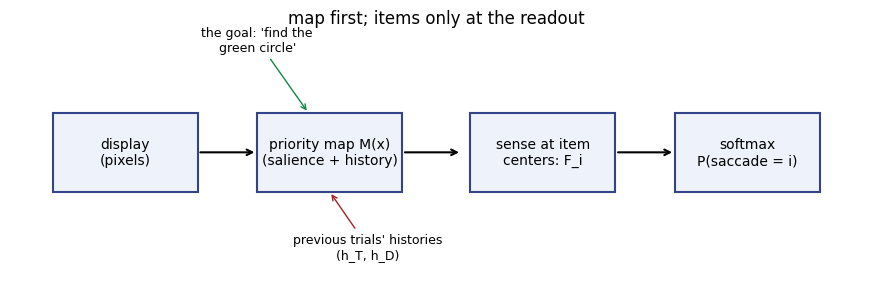

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
boxes = [(0.05, "display\n(pixels)"),
         (0.29, "priority map M(x)\n(salience + history)"),
         (0.54, "sense at item\ncenters: F_i"),
         (0.78, "softmax\nP(saccade = i)")]
for x, label in boxes:
    ax.add_patch(plt.Rectangle((x, 0.35), 0.17, 0.32, fc="#eef2fa",
                               ec="#334488", lw=1.5))
    ax.text(x + 0.085, 0.51, label, ha="center", va="center", fontsize=10)
for x, _ in boxes[:-1]:
    ax.annotate("", xy=(x + 0.24, 0.51), xytext=(x + 0.17, 0.51),
                arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("the goal: 'find the\ngreen circle'", xy=(0.35, 0.67),
            xytext=(0.29, 0.92), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#118844"))
ax.annotate("previous trials' histories\n(h_T, h_D)", xy=(0.375, 0.35),
            xytext=(0.42, 0.08), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#aa2222"))
ax.set_xlim(0, 1.0); ax.set_ylim(0, 1); ax.axis("off")
plt.title("map first; items only at the readout")
plt.show()

## 2. The displays: one example per study

Eleven experiments, pooled. Each subject searched one fixed shape
all session, so displays are reconstructed canonically: a CIRCLE
target among mixed other shapes, green items, one red color
singleton. The target never pops out — it is found by shape; the
singleton does pop out. (Each study's own color pair is shown here
for flavor; Hamblin-Frohman ships no color labels, so it falls
back to green/red.)

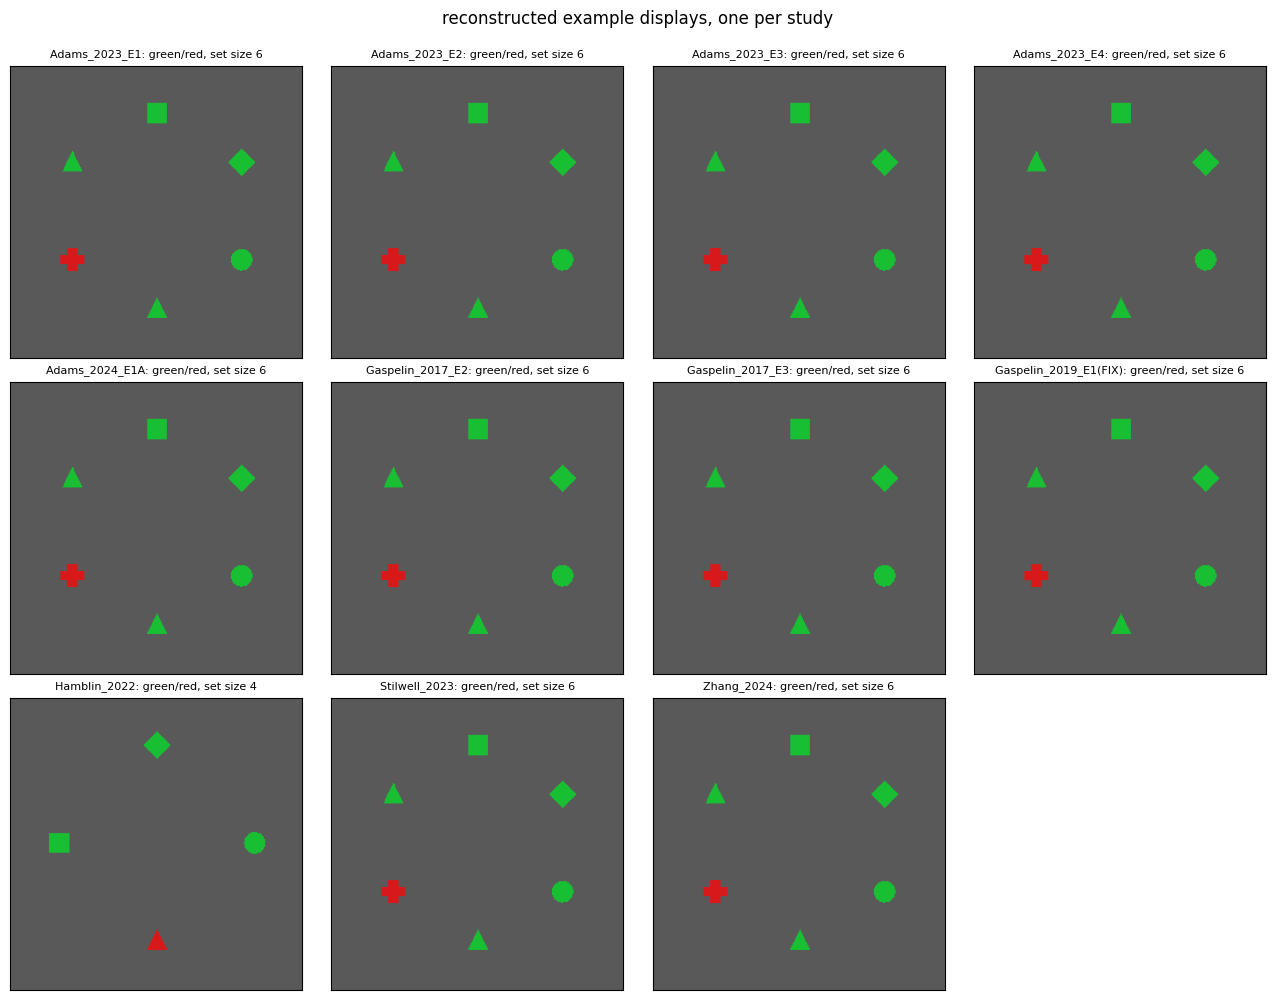

In [3]:
gal = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False,
                  usecols=["study", "setsize", "targCol", "singCol"])
gal = gal[gal.singCol != "none"]

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax, (study, sub) in zip(axes.flat, gal.groupby("study")):
    setsize = int(sub.setsize.mode()[0])
    tc, sc = sub[["targCol", "singCol"]].mode().iloc[0]
    ipos, _ = item_positions(setsize)
    tg, sg = 2, (2 + setsize // 2) % setsize + 1   # target & singleton slots
    items = [dict(x=ipos[j][0], y=ipos[j][1],
                  color=sc if (j + 1) == sg else tc,
                  shape=shape_for(j + 1, tg)) for j in range(setsize)]
    ax.imshow(render(items), origin="lower")
    ax.set_title(f"{study}: {tc}/{sc}, set size {setsize}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[gal.study.nunique():]:
    ax.axis("off")
plt.suptitle("reconstructed example displays, one per study", y=0.995)
plt.tight_layout()
plt.show()

## 3. From one display to the goal-modified salience map

Follow one display through the perception stage.

**The color pathway.** The raw color-contrast map (how much each
pixel's color stands out from the gray background) is PROJECTED
onto the goal's color direction, giving the signed map `D_T`:
positive at goal-colored items (green), negative at the
opposite-colored singleton (red), near zero elsewhere. The goal
then enters through one gain:

    g_C * D_T

Turning `g_C` up lifts the green items AND deepens the singleton's
hole with the same knob — enhancement and suppression are two
sides of one modulation. (An earlier form used two separate
rectified gains; two-color displays identify only their
combination — RESULTS — so the record carries one signed gain.)

The gains below are placeholders; §7 learns the real ones. Each
panel is scaled to its own maximum — compare magnitudes by the
color bars, not the color intensity.

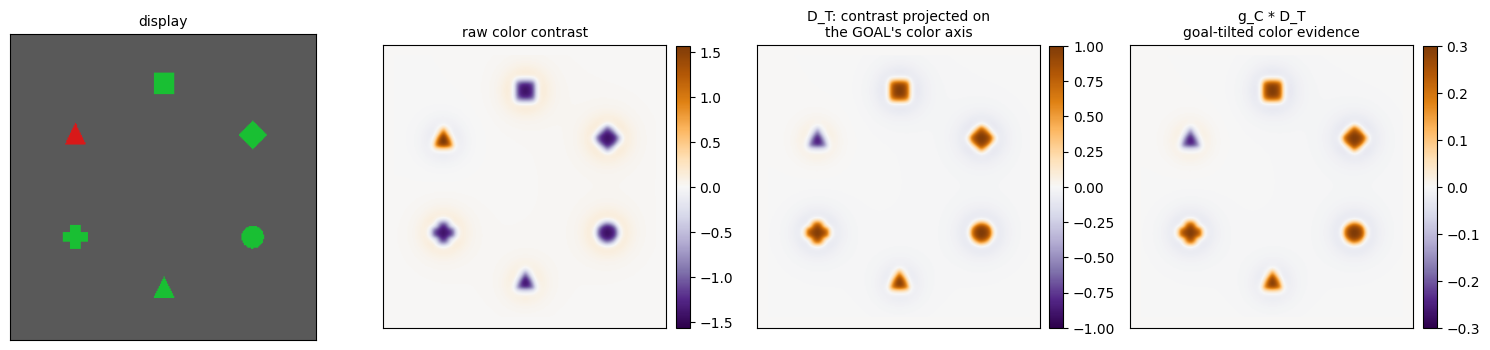

In [4]:
# placeholder gains - magnitudes picked so the demo maps and the
# Sec. 6 worked example are visibly structured (training replaces
# them with fitted values)
gC_demo, gF_demo = 0.3, 14.0

TARG, SING = 1, 4
items = [dict(x=pos[j][0], y=pos[j][1],
              color="red" if j == SING else "green",
              shape=shape_for(j + 1, TARG + 1)) for j in range(6)]
img = render(items)
maps = opponency_contrast(img)
u = template_axis("green")            # the goal color, as a direction
goal_map = u[0]*maps["RG"] + u[1]*maps["BY"]     # D_T: + green, - red
# greyscale: divide by the strongest |D_T| pixel (a fixed constant),
# so color pixels lie in [-1, 1] and full scale is 1
C_COLOR = np.abs(goal_map).max()
goal_map = goal_map / C_COLOR
color_evidence = gC_demo * goal_map              # ONE goal gain

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
axes[0].imshow(img, origin="lower"); axes[0].set_title("display", fontsize=10)
v = np.abs(maps["RG"]).max()
im1 = axes[1].imshow(maps["RG"], origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
axes[1].set_title("raw color contrast", fontsize=10)
v2 = np.abs(goal_map).max()
im2 = axes[2].imshow(goal_map, origin="lower", cmap="PuOr_r",
                     vmin=-v2, vmax=v2)
axes[2].set_title("D_T: contrast projected on\nthe GOAL's color axis",
                  fontsize=10)
v3 = np.abs(color_evidence).max()
im3 = axes[3].imshow(color_evidence, origin="lower", cmap="PuOr_r",
                     vmin=-v3, vmax=v3)
axes[3].set_title("g_C * D_T\ngoal-tilted color evidence", fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in zip(axes[1:], [im1, im2, im3]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

Read the panels left to right: raw contrast, its projection onto
the goal's color axis (`D_T`), and `g_C * D_T` — green items up,
singleton below zero, one knob.

**Adding shape.** The shape map is color-blind: how circle-like
each location's contour is, computed from the pixels by template
matching (circle match minus the best competing shape's match).
Its gain `g_F` raises the one circle-shaped location — the target.
The **goal-modified salience map** is the pixel-wise sum:

    g_C * D_T + g_F * shape

Both maps are GREYSCALE: color pixels run from -1 to +1 (full
scale = the strongest color pixel the canonical display produces),
shape from 0 to 1. So `g_C` and `g_F` are on equal footing — each
is the priority of a full-strength pixel of its channel.

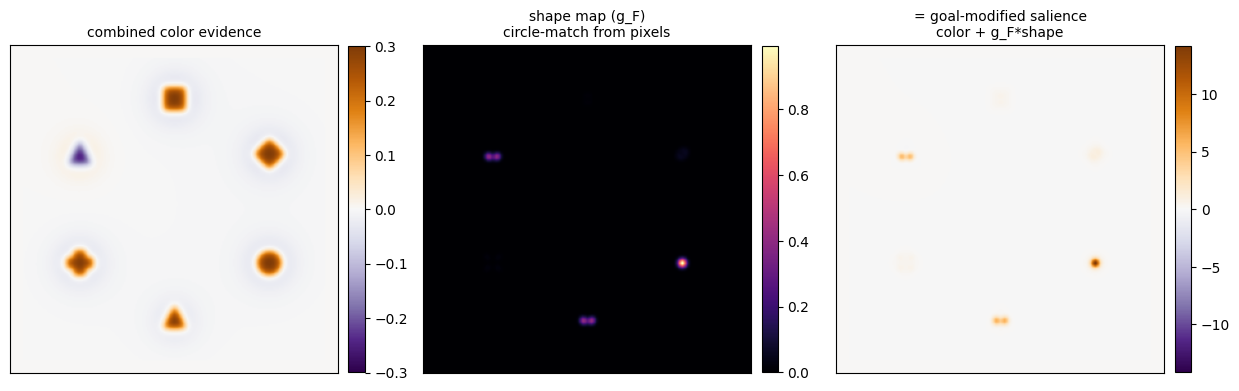

In [5]:
smap = shape_match_map(render(items, scale=2))
smap = smap[::2, ::2] / max(smap.max(), 1e-9)  # greyscale: peak 1
salience = color_evidence + gF_demo * smap

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
v = np.abs(color_evidence).max()
im0 = axes[0].imshow(color_evidence, origin="lower", cmap="PuOr_r",
                     vmin=-v, vmax=v)
axes[0].set_title("combined color evidence", fontsize=10)
im1 = axes[1].imshow(smap, origin="lower", cmap="magma")
axes[1].set_title("shape map (g_F)\ncircle-match from pixels",
                  fontsize=10)
v = np.abs(salience).max()
im2 = axes[2].imshow(salience, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
axes[2].set_title("= goal-modified salience\ncolor + g_F*shape",
                  fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in zip(axes, [im0, im1, im2]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

In the final map the target is doubly bright (right color AND
right shape), plain green items carry color evidence only, and the
red singleton is a signed hole. Orange = positive, purple =
negative.

Two features of the shape map worth a second look:

- **The bright spot is smaller than the circle.** Each pixel
  answers "is a circle centered HERE?" — a template-ALIGNMENT
  peak, not a filled disk. That is all the model needs: shape is
  read exactly at item centers.
- **Faint dots at the triangles.** Just off a triangle's center
  the circle template briefly beats the triangle template (circles
  forgive misalignment; triangles don't), leaving thin rims of
  weak false match — the honest fingerprint of computing shape
  from pixels, ~6x weaker than the real circle's peak. Color plays
  no role: the image is binarized before shape matching.

## 4. Location-based selection history

The model remembers WHERE things have been — not what they looked
like. Two memories, one number per location, updated after every
trial as leaky accumulators:

    h = (1 - eta) * h              # everything fades a little
    h[location] += eta             # this trial's location gets a boost

`h_T` tracks target locations (recency weight `eta_T`); `h_D`
tracks distractor locations (`eta_D`). Each entry is a recency-weighted
occupancy between 0 and 1 — NOT a probability; nothing normalizes
across locations. `eta` is the weight on the newest
trial: large `eta` — recent trials dominate; small `eta` — many
past trials average together. Their map gains are
`beta_T` (past target locations PULL the eyes) and `beta_D`
(negative: past distractor locations PUSH away).

Three panels below:

1. **the accumulator** — `accumulate_history` (reused verbatim by
   the final model in §6), replayed over a ten-trial demo history:
   location 2's `h` at a large and a small `eta`;
2. **the history VECTOR** — one number per item:
   `beta_T*hT_i + beta_D*hD_i`;
3. **the history MAP** — that vector painted at the item locations
   with the fixed kernel (`selection_history_map`, sigma 0.03,
   peak 1). Added to the salience map in §5, it completes the
   priority map.

h_T: [0.   0.71 0.04 0.24 0.   0.01]  (targets, eta_T = 0.6 )
h_D: [0.05 0.   0.   0.7  0.   0.  ]  (singletons, eta_D = 0.2 )
history vector: [-2.60e-02  1.43e+00  7.70e-02  1.32e-01  1.00e-03  1.20e-02]


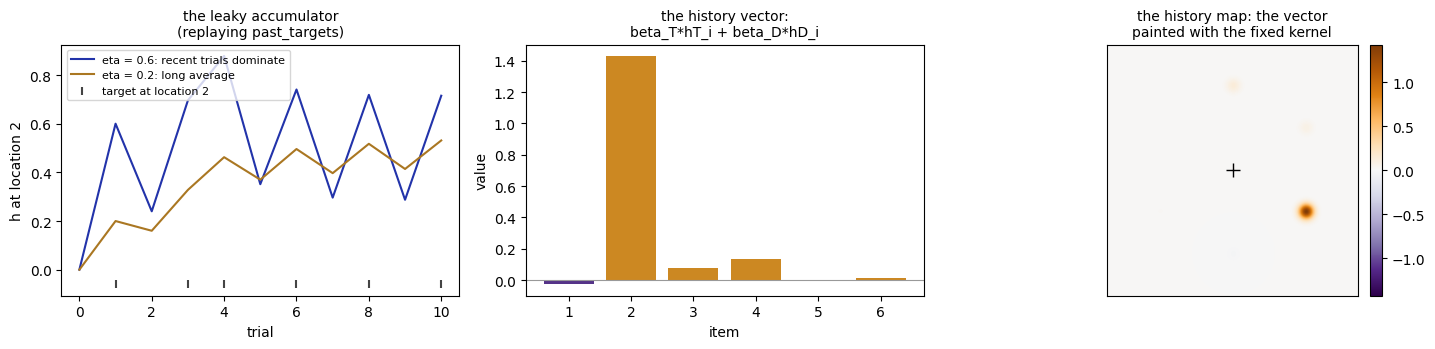

In [6]:
def accumulate_history(past_locs, eta):
    '''The leaky accumulator above, replayed over past trials.
    past_locs: where the item appeared on each previous trial
    (1-6; 0 = absent), oldest first. After each trial everything
    fades by (1 - eta) and that trial's location gets an eta boost.
    (A torch eta makes h a tensor, so Sec. 7's training can take
    gradients through the replay.)'''
    h = torch.zeros(6) if torch.is_tensor(eta) else np.zeros(6)
    for loc in past_locs:
        h = (1 - eta) * h
        if loc:
            h[int(loc) - 1] += eta
    return h

# the demo trial history, reused all the way to the Sec. 7 worked
# example: where things appeared on the ten previous trials,
# oldest first (1-6 = item location, 0 = absent)
past_targets    = [2, 5, 2, 2, 6, 2, 3, 2, 4, 2]   # target favored loc 2
past_singletons = [4, 4, 0, 1, 4, 4, 0, 4, 4, 4]   # singleton favored loc 4
etaT_demo, etaD_demo = 0.6, 0.2                    # demo memory speeds

# replay the SAME target history at two eta values, watch location 2
n_tr = len(past_targets)
h_fast = np.zeros((n_tr + 1, 6)); h_slow = np.zeros((n_tr + 1, 6))
for t in range(n_tr):
    h_fast[t+1] = accumulate_history(past_targets[:t+1], 0.6)
    h_slow[t+1] = accumulate_history(past_targets[:t+1], 0.2)

cx = cy = IMG / 2
px_per_unit = IMG / 1.5
yy, xx = np.mgrid[0:IMG, 0:IMG]

def selection_history_map(vals, sig=0.03):
    # each bump is the fixed Gaussian kernel with PEAK HEIGHT 1 -
    # the natural unit for a readout that SENSES the map at item
    # centers (Sec. 6): a fully primed own location senses as
    # exactly beta, and sig sets only how far the bump spreads.
    # Torch-ready: with torch vals (Sec. 7) the bump joins them as
    # a tensor so gradients reach the betas and etas
    m = 0.0
    for j in range(6):
        px, py = (pos[j][0]+0.75)/1.5*IMG, (pos[j][1]+0.75)/1.5*IMG
        bump = np.exp(-((xx-px)**2 + (yy-py)**2)
                      / (2*(sig*px_per_unit)**2))
        if torch.is_tensor(vals):
            bump = torch.as_tensor(bump)
        m = m + vals[j] * bump
    return m

# the two memories after those ten trials, built by the same
# accumulate_history the final model reuses in Sec. 7
hT_demo = accumulate_history(past_targets, etaT_demo)
hD_demo = accumulate_history(past_singletons, etaD_demo)
print("h_T:", hT_demo.round(2), " (targets, eta_T =", etaT_demo, ")")
print("h_D:", hD_demo.round(2), " (singletons, eta_D =", etaD_demo, ")")
betaT_demo, betaD_demo = 2.0, -0.5      # placeholder gains (near the
                                        # fitted values)

# ---- the history VECTOR: one number per item location ----
hist_vec = betaT_demo*hT_demo + betaD_demo*hD_demo
print("history vector:", hist_vec.round(3))

# ---- the history MAP: the vector painted with the fixed kernel ----
history_map = selection_history_map(hist_vec)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
axes[0].plot(h_fast[:, 1], color="#2233aa", label="eta = 0.6: recent trials dominate")
axes[0].plot(h_slow[:, 1], color="#aa7722", label="eta = 0.2: long average")
hit_tr = [t + 1 for t, loc in enumerate(past_targets) if loc == 2]
axes[0].scatter(hit_tr, np.full(len(hit_tr), -0.06),
                marker="|", color="#444444", label="target at location 2")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("h at location 2")
axes[0].set_title("the leaky accumulator\n(replaying past_targets)", fontsize=10)
axes[0].legend(fontsize=8)
cols = ["#cc8822" if v_ >= 0 else "#553388" for v_ in hist_vec]
axes[1].bar(range(1, 7), hist_vec, color=cols)
axes[1].axhline(0, color="#999999", lw=0.8)
axes[1].set_xlabel("item"); axes[1].set_ylabel("value")
axes[1].set_title("the history vector:\n"
                  "beta_T*hT_i + beta_D*hD_i", fontsize=10)
v = np.abs(history_map).max()
im_p = axes[2].imshow(history_map, origin="lower", cmap="PuOr_r",
                      vmin=-v, vmax=v)
axes[2].plot(IMG/2, IMG/2, "k+", ms=10)
axes[2].set_title("the history map: the vector\n"
                  "painted with the fixed kernel", fontsize=10)
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im_p, ax=axes[2], fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

## 5. Combining stimulus and history into one map

The priority map is a pixel-by-pixel SUM: the goal-modified
salience map (§3) plus the history map (§4). Stimulus evidence and
selection history compete in the same currency, in one 2-D object
— and that sum IS the map the readout senses (§6).

    priority(x) = salience(x) + history_map(x)

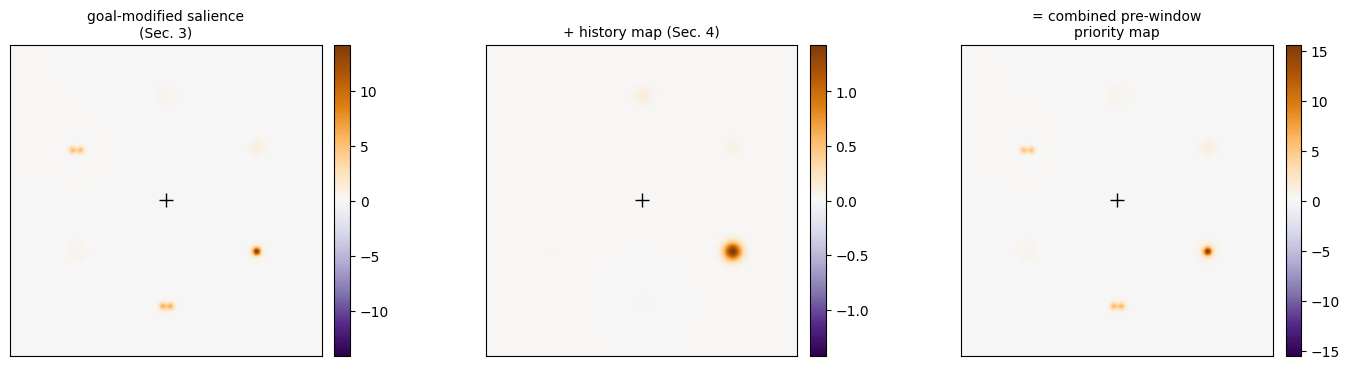

In [7]:
combined = salience + history_map      # THE priority map

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.8))
for ax, m, ttl in [(axes[0], salience, "goal-modified salience\n(Sec. 3)"),
                   (axes[1], history_map, "+ history map (Sec. 4)"),
                   (axes[2], combined, "= combined pre-window\npriority map")]:
    v = max(np.abs(m).max(), 1e-9)
    im = ax.imshow(m, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
    ax.plot(IMG/2, IMG/2, "k+", ms=10)
    ax.set_title(ttl, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

## 6. The final model, in two small functions

Everything above, assembled — nothing new:

1. **`priority_map`** (§3-5): goal-modified salience
   (`g_C`*D_T + `g_F`*shape) plus the painted history field. That
   sum IS the priority map;
2. **`predict_saccade`** (§1 steps 2-3): sense the map at the six
   item centers, softmax into P(first saccade).

All six parameters act inside these functions — the etas run §4's
`accumulate_history` on the raw past-trial locations, the betas
weigh the result, the g's do their §3 job.

In [8]:
# accumulate_history and selection_history_map are Sec. 4's - reused, not redefined

def priority_map(img, past_targets, past_singletons,
                 g_C, g_F, beta_T, beta_D, eta_T, eta_D,
                 target_color="green"):
    '''The priority map M(x) of Sec. 1, from raw inputs:
    the display image plus the RAW TRIAL HISTORY - the lists of
    where the target and the singleton appeared on previous trials.

    All of Sec. 1's history parameters act here: eta_T, eta_D run
    the Sec. 4 accumulators over the past (how the past is
    compressed into h_T, h_D), and beta_T, beta_D weigh the result
    in the map.'''
    cmaps = opponency_contrast(img)                      # Sec. 3, line for line
    u_ = template_axis(target_color)
    gmap = u_[0]*cmaps["RG"] + u_[1]*cmaps["BY"]         # signed D_T
    gmap = gmap / C_COLOR              # greyscale: pixels in [-1, 1]
    # the fixed maps become tensors HERE, where they meet the learned
    # gains - so Sec. 7's training can differentiate through this map
    gmap = torch.as_tensor(gmap)
    sm = shape_match_map(img)
    sm = torch.as_tensor(sm / max(sm.max(), 1e-9))   # greyscale: peak 1
    salience = g_C*gmap + g_F*sm                         # Sec. 3
    h_T = accumulate_history(past_targets, eta_T)        # Sec. 4
    h_D = accumulate_history(past_singletons, eta_D)
    history_field = selection_history_map(beta_T*h_T + beta_D*h_D)
    # as_tensor: no-op for torch history (gradients intact), converts
    # numpy history - so the sum never mixes tensor with ndarray
    return salience + torch.as_tensor(history_field)


def predict_saccade(pm):
    '''Takes the OUTPUT of priority_map() - the 2-D priority map -
    and SENSES it at each item's center (F_i = M(x_i), Sec. 1
    steps 2-3), like a range sensor reading one value per
    direction; then softmaxes the six sensed values into
    P(first saccade = i).'''
    pm = torch.as_tensor(pm)      # keeps gradients when pm carries them
    priorities = []
    for j_ in range(6):
        px_ = int(round((pos[j_][0] + 0.75) / 1.5 * IMG))
        py_ = int(round((pos[j_][1] + 0.75) / 1.5 * IMG))
        priorities.append(pm[py_, px_])
    F_ = torch.stack(priorities).float()[None]
    return torch.softmax(F_, 1), F_

print("the model: priority_map -> predict_saccade")

the model: priority_map -> predict_saccade


### One worked example, raw image to prediction

The §3 display and the §4 histories go in with placeholder
weights; out come the map, the six sensed priorities, and the
prediction. (With these placeholder gains the history bump at
item 2 dominates; §7 learns the real balance.)

priority per item: [ 1.94 15.73  0.57  1.4   1.45  0.42]
P(first saccade):  [  0. 100.   0.   0.   0.   0.] %
most likely saccade: item 2 (the target; one PREDICTED saccade = one draw from these)


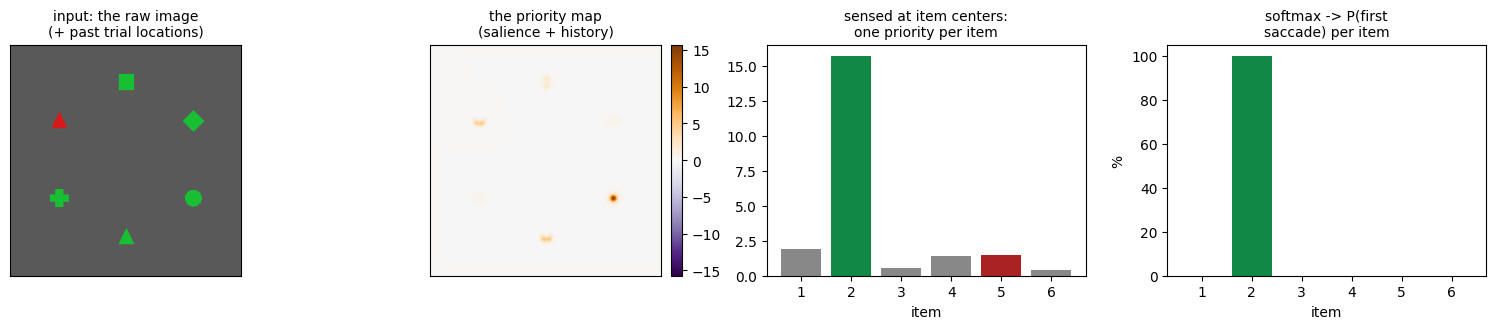

In [9]:
# the six Sec. 1 parameters, in one place
PARAMS = dict(g_C=gC_demo, g_F=gF_demo,
              beta_T=betaT_demo, beta_D=betaD_demo,
              eta_T=etaT_demo, eta_D=etaD_demo)

pm = priority_map(img, past_targets, past_singletons, **PARAMS)
p_ex, F_ex = predict_saccade(pm)

print("priority per item:", F_ex[0].numpy().round(2))
print("P(first saccade): ", (p_ex[0].numpy() * 100).round(1), "%")
print("most likely saccade: item", int(F_ex[0].argmax()) + 1,
      "(the target; one PREDICTED saccade = one draw from these)")

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.4))
axes[0].imshow(img, origin="lower")
axes[0].set_title("input: the raw image\n(+ past trial locations)", fontsize=10)
pm_np = np.asarray(pm)
v = np.abs(pm_np).max()
im = axes[1].imshow(pm_np, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
axes[1].set_title("the priority map\n(salience + history)", fontsize=10)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.03)
for ax in axes[:2]:
    ax.set_xticks([]); ax.set_yticks([])
cols = ["#888888"] * 6
cols[TARG], cols[SING] = "#118844", "#aa2222"
axes[2].bar(range(1, 7), F_ex[0].numpy(), color=cols)
axes[2].set_title("sensed at item centers:\none priority per item", fontsize=10)
axes[2].set_xlabel("item")
axes[3].bar(range(1, 7), p_ex[0].numpy() * 100, color=cols)
axes[3].set_title("softmax -> P(first\nsaccade) per item", fontsize=10)
axes[3].set_xlabel("item"); axes[3].set_ylabel("%")
plt.tight_layout()
plt.show()

## 7. Train on the actual data

The dataset holds every first saccade from 333 people, plus the
full trial order (needed to rebuild each person's memories).
Excluded at pooling (`pool_data.py`): trials with motion/onset
singletons, and Stilwell's low-salience trials — the latter kept
entirely outside the model as the out-of-sample test in §9.

We hold out 20% of the PEOPLE and fit by maximum likelihood:
replay everyone's trials, score the probability the model gave the
real eye movement, nudge all six numbers by gradient descent.

**Why not call `priority_map()` directly in the loop?** It works —
an earlier revision did it — but one forward-and-backward through
the pixels costs ~60 ms, and 114,232 saccades x 500 epochs is ~40
days of re-rendering the SAME images: between epochs only the six
parameters change.

So we cache what the parameters never touch, and the point-sensing
readout makes that cache tiny: per display, the two channel maps'
values at six pixels, plus the history kernel between the centers.
`priority_map` builds its own cache — the map is linear in the
gains, so calling it with `g_C = 1` (other gain 0) returns exactly
the map g_C multiplies, likewise `g_F`. Each epoch reassembles the
sensed values with the current parameters. Nothing is
approximated; the next cell proves it on a trial.

In [10]:
# build the exact cache: the Sec. 7 model, sensed at the item centers
import data

sacc = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False)  # a row per first saccade
ev = pd.read_csv("dataset/events.csv", low_memory=False)          # a row per trial
sacc, tt = data.build_tensors(sacc, ev)   # a few minutes: aligns everything
N = len(sacc)

def display_for(setsize, targ, sing, tc="green", sc="red"):
    '''Re-render a display from its trial parameters (Sec. 2/3).'''
    ipos, _ = item_positions(setsize)
    return render([dict(x=ipos[j][0], y=ipos[j][1],
                        color=(sc if j + 1 == sing else tc),
                        shape=shape_for(j + 1, targ)) for j in range(setsize)])

UNIT = dict(beta_T=0.0, beta_D=0.0, eta_T=0.5, eta_D=0.5)  # history off
def channel_maps(img_, tc="green"):
    # priority_map with a single unit gain returns exactly the map that
    # gain multiplies (the priority map is linear in the gains)
    return torch.stack([torch.as_tensor(np.asarray(
        priority_map(img_, [], [], **g, **UNIT, target_color=tc)))
        for g in (dict(g_C=1.0, g_F=0.0),
                  dict(g_C=0.0, g_F=1.0))])

def centers(setsize):
    # the sensed pixels: each item's center (Sec. 6's predict_saccade)
    ipos, _ = item_positions(setsize)
    return [(int(round((p[1]+0.75)/1.5*IMG)), int(round((p[0]+0.75)/1.5*IMG)))
            for p in ipos]

# every display any saccade saw, sensed: A_CH[display, item, channel]
keys = sorted(set(zip(sacc.setsize.astype(int),
                      sacc.targLoc.astype(int), sacc.singLoc.astype(int))))
A_CH = torch.zeros(len(keys), 6, 2)
for d_, key in enumerate(keys):
    ch = channel_maps(display_for(*key))
    for j_, (py_, px_) in enumerate(centers(key[0])):
        A_CH[d_, j_] = ch[:, py_, px_].float()
# no extra unit step: the channels are greyscale (Sec. 3), so the
# cached values already ARE the model's units
DIDX = {key: i for i, key in enumerate(keys)}
didx = torch.tensor([DIDX[key] for key in
                     zip(sacc.setsize.astype(int), sacc.targLoc.astype(int),
                         sacc.singLoc.astype(int))])

# the Sec. 4 history kernel sensed between item centers (peak 1 at
# its own center, ~0 at the neighbors), per set size
B_HIST = {}
for s_ in (6, 4):
    ipos, _ = item_positions(s_)
    cs = centers(s_)
    Bm = np.zeros((6, 6))
    for j_ in range(s_):
        pxj = (ipos[j_][0]+0.75)/1.5*IMG; pyj = (ipos[j_][1]+0.75)/1.5*IMG
        bump = np.exp(-((xx-pxj)**2 + (yy-pyj)**2)
                      / (2*(0.03*px_per_unit)**2))
        for i_ in range(s_):
            Bm[i_, j_] = bump[cs[i_][0], cs[i_][1]]
    B_HIST[s_] = torch.tensor(Bm)
m6 = torch.tensor((sacc.setsize == 6).values)

n_subj = tt["eT"].shape[0]
rng = np.random.default_rng(0)
test_subj = torch.zeros(n_subj, dtype=torch.bool)
test_subj[rng.choice(n_subj, n_subj // 5, replace=False)] = True
test = test_subj[tt["si"]]; train = ~test
print(f"{N} saccades, {len(keys)} displays sensed "
      f"({A_CH.numel()} cached numbers); "
      f"{int((~test_subj).sum())} people to train on, "
      f"{int(test_subj.sum())} held out")

114232 saccades, 52 displays sensed (624 cached numbers); 267 people to train on, 66 held out


**Sanity check.** One trial through both routes with the same
parameters: raw pixels through `priority_map()` ->
`predict_saccade()`, and the cached reassembly. The six priorities
must agree to float precision — then training on the cache IS
training the §6 model.

In [11]:
def cached_F(key, h_T, h_D, g_C, g_F, beta_T, beta_D):
    # reassemble the six SENSED priorities from cached pieces
    s_ = key[0]
    ch = channel_maps(display_for(*key))   # greyscale, matching the
    vals = torch.as_tensor(beta_T*h_T + beta_D*h_D)  # literal model exactly
    F_ = []
    for i_, (py_, px_) in enumerate(centers(s_)):
        sal = g_C*ch[0, py_, px_] + g_F*ch[1, py_, px_]
        hist = (vals[:s_] * B_HIST[s_][i_, :s_]).sum()
        F_.append(sal + hist)
    return torch.stack(F_)

pt, ps = past_targets, past_singletons          # the Sec. 4 demo history
key0 = (6, 1, 4)                      # target slot 1, singleton slot 4
F_lit = predict_saccade(priority_map(display_for(*key0), pt, ps, **PARAMS))[1][0]
F_c = cached_F(key0,
               accumulate_history(pt, PARAMS["eta_T"]),
               accumulate_history(ps, PARAMS["eta_D"]),
               PARAMS["g_C"], PARAMS["g_F"],
               PARAMS["beta_T"], PARAMS["beta_D"])
print("literal:", F_lit.numpy().round(6))
print("cached: ", F_c.float().numpy().round(6))
print(f"max |difference|: {float((F_lit - F_c.float()).abs().max()):.2e}")

literal: [14.273746  1.829853  0.572017  0.84332   1.932046  0.415719]
cached:  [14.273746  1.829853  0.572017  0.84332   1.932046  0.415719]
max |difference|: 0.00e+00


### The fit, at scale

Per epoch: replay the memories (the etas are learning) and
reassemble every saccade's six priorities from the cached values —
under a second per epoch for all 114,232 saccades. Set-size-4
displays (Hamblin 2022) sense four centers. No unit bookkeeping:
the channels are greyscale (§3), so the cached values already are
the model's units.

epoch 0: loss 1.5298


epoch 25: loss 1.4276


epoch 50: loss 1.4247


epoch 75: loss 1.4235


epoch 100: loss 1.4231


...

epoch 375: loss 1.4229


epoch 400: loss 1.4229


epoch 425: loss 1.4229


epoch 450: loss 1.4229


epoch 475: loss 1.4229


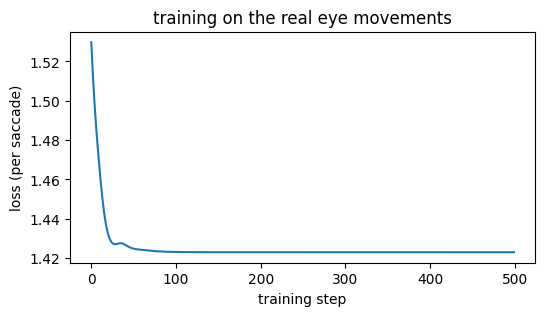

In [12]:
def build_memories(eta_T, eta_D):
    # replay every subject's trials in order; memory AS OF each trial
    S_, T_, _ = tt["eT"].shape
    hT = torch.zeros(S_, 6); hD = torch.zeros(S_, 6)
    outT, outD = [], []
    for t in range(T_):
        outT.append(hT); outD.append(hD)
        hT = (1 - eta_T) * hT + eta_T * tt["eT"][:, t]
        hD = (1 - eta_D) * hD + eta_D * tt["eD"][:, t]
    return torch.stack(outT, 1), torch.stack(outD, 1)

def model_F(w, raw_eta):
    '''Every saccade's six SENSED priorities: the Sec. 6 model
    reassembled from the cache. Between epochs only the memories
    are recomputed; the gains just reweigh cached numbers.'''
    eta_T = torch.sigmoid(raw_eta["T"]); eta_D = torch.sigmoid(raw_eta["D"])
    memT, memD = build_memories(eta_T, eta_D)
    hT = memT[tt["si"], tt["ti"]]; hD = memD[tt["si"], tt["ti"]]
    vals = w["beta_T"] * hT + w["beta_D"] * hD
    Ad = A_CH[didx]                                # sensed channels
    sal = w["g_C"]*Ad[..., 0] + w["g_F"]*Ad[..., 1]
    F = torch.zeros(N, 6)
    for s_ in (6, 4):
        msk = m6 if s_ == 6 else ~m6
        F[msk] = sal[msk] + vals[msk] @ B_HIST[s_].float().T
    return F, memT, memD

w = {name: torch.tensor(v, requires_grad=True) for name, v in
     [("g_C", 0.5), ("g_F", 1.0),
      ("beta_T", 0.5), ("beta_D", -0.1)]}
raw_eta = {n: torch.tensor(0.0, requires_grad=True) for n in ["T", "D"]}
optimizer = torch.optim.Adam(list(w.values()) + list(raw_eta.values()),
                             lr=0.05)

losses = []
for epoch in range(500):
    F, _, _ = model_F(w, raw_eta)
    F = F.masked_fill(~tt["valid"], -1e9)     # empty slots can never be chosen
    logp = torch.log_softmax(F, 1).gather(    # softmax -> P(item); keep the
        1, tt["choice"][:, None]).squeeze(1)  # probability of the REAL choice
    loss = -logp[train].mean()                # maximize likelihood
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
    if epoch % 25 == 0:
        print(f"epoch {epoch}: loss {loss.item():.4f}", flush=True)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("training step"); plt.ylabel("loss (per saccade)")
plt.title("training on the real eye movements")
plt.show()

In [13]:
learned = {k: v.item() for k, v in w.items()}
learned["eta_T"] = torch.sigmoid(raw_eta["T"]).item()
learned["eta_D"] = torch.sigmoid(raw_eta["D"]).item()
for name, meaning in [
        ("g_C", "up-weights target color, down-weights distractor color"),
        ("g_F", "up-weights the target shape"),
        ("beta_T", "pull toward past target locations"),
        ("beta_D", "push from past distractor locations"),
        ("eta_T", "weight on recent target locations"),
        ("eta_D", "weight on recent distractor locations")]:
    print(f"{name:8} = {learned[name]:+7.3f}   {meaning}")

g_C      =  +0.352   up-weights target color, down-weights distractor color
g_F      =  +1.381   up-weights the target shape
beta_T   =  +2.119   pull toward past target locations
beta_D   =  -0.485   push from past distractor locations
eta_T    =  +0.597   weight on recent target locations
eta_D    =  +0.149   weight on recent distractor locations


## 8. Evaluation: how good is it? (held-out people only)

Scored ONLY on people the model never saw. Three measures:

- **Mean probability on the true choice** — the geometric-mean
  probability the model assigned to the item actually fixated.
  Chance: 1/(items on screen), ~18% here.
- **Top-1 accuracy** — how often the actual choice was the model's
  highest-probability item. Chance ~18%.
- **Pseudo-R-squared** — `1 - NLL_model / NLL_chance`. 0 = no
  better than guessing; 1 = perfect. For human choice data,
  0.2-0.4 counts as excellent — the same person, display, and
  history does not always yield the same saccade, so 1.0 is
  unreachable in principle.

In [14]:
with torch.no_grad():
    F, memT, memD = model_F(w, raw_eta)
    F = F.masked_fill(~tt["valid"], -1e9)
    prob = torch.softmax(F, 1)
    p_true = prob.gather(1, tt["choice"][:, None]).squeeze(1)

nll = -p_true[test].log().mean()
chance = torch.log(tt["valid"].sum(1).float())[test].mean()
print(f"held-out saccades: {int(test.sum())}")
print(f"mean probability on the true choice: "
      f"{p_true[test].log().mean().exp()*100:.1f}%  "
      f"(chance {torch.exp(-chance)*100:.1f}%)")
print(f"top-1 accuracy: "
      f"{(prob.argmax(1) == tt['choice'])[test].float().mean()*100:.1f}%")
print(f"pseudo-R-squared vs chance: {1 - nll/chance:.3f}")
print(f"held-out NLL per saccade: {nll:.5f}")

held-out saccades: 23216
mean probability on the true choice: 25.3%  (chance 17.4%)
top-1 accuracy: 45.7%
pseudo-R-squared vs chance: 0.214
held-out NLL per saccade: 1.37415


**Interpretation.** The model roughly halves a stranger's
first-saccade uncertainty: ~25% geometric-mean probability on the
true choice vs ~18% chance, the right item as top guess almost
half the time, pseudo-R-squared ~0.2. For calibration:
memorization benchmarks built from the training people (choice
frequencies per display, even per person) score WORSE — the graded
history traces carry information no frequency table can (RESULTS,
"Oracle benchmarks").

## 9. Does it behave like people? Three signature patterns

Held-out people only; nothing below was fitted to these patterns —
they fall out of the one trained equation.

**9a. Oculomotor suppression.** First saccades go to the salient
red singleton LESS often than to an average plain item — the
below-baseline suppression this dataset exists to measure.

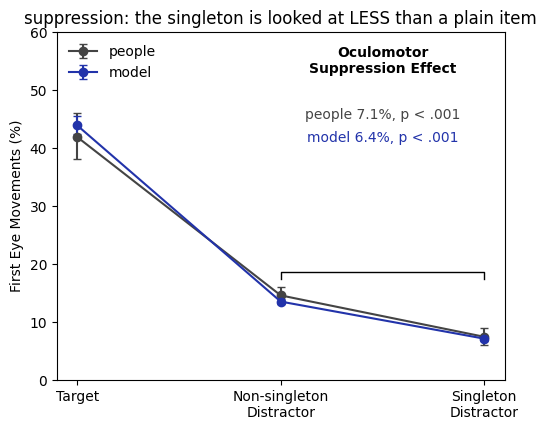

people: non-singleton vs singleton distractor (paired across 66 held-out subjects)
      T  dof alternative  p_val         CI95  cohen_d  power      BF10
10.7883   65   two-sided    0.0 [5.82, 8.47]   1.2096    1.0 1.599e+13 

model: non-singleton vs singleton distractor (paired across 66 held-out subjects)
      T  dof alternative  p_val         CI95  cohen_d  power      BF10
20.3682   65   two-sided    0.0 [5.77, 7.02]   3.3603    1.0 4.663e+26 



In [15]:
first = torch.tensor((sacc.saccindex == 1).values)  # all True: the scope
sing_present = torch.tensor((sacc.singLoc > 0).values)
rows = torch.arange(N)
isT = torch.zeros(N, 6); isT[rows, torch.tensor(sacc.targLoc.values) - 1] = 1
isS = torch.zeros(N, 6)
sp = torch.tensor(sacc.singLoc.values)
isS[rows[sp > 0], sp[sp > 0] - 1] = 1
chose = torch.zeros(N, 6); chose[rows, tt["choice"]] = 1

m = test & first & sing_present

# REGENERATE the test saccades: one model saccade per real trial,
# drawn from the predicted probabilities (each trial conditioned on
# the subject's actual history). The model line then carries the
# same trial-count binomial noise as the people line, so its error
# bars and t-test are commensurable with the data's.
gen = torch.Generator().manual_seed(0)
sim = torch.multinomial(prob[m], 1, generator=gen).squeeze(1)
simch = torch.zeros(int(m.sum()), 6)
simch[torch.arange(int(m.sum())), sim] = 1

# per-person rates: each held-out subject contributes one mean per
# item type; points = mean over people, error bars = bootstrapped
# 95% CI (resampling subjects)
per = pd.DataFrame(dict(
    si=tt["si"][m].numpy(),
    obs_t=(chose[m]*isT[m]).sum(1).numpy(),
    obs_s=(chose[m]*isS[m]).sum(1).numpy(),
    mod_t=(simch*isT[m]).sum(1).numpy(),
    mod_s=(simch*isS[m]).sum(1).numpy(),
    n_pl=(tt["valid"][m].sum(1).float() - 2).clamp(min=1).numpy()))
for w_ in ("obs", "mod"):    # plain-item average per saccade
    per[w_ + "_ns"] = (1 - per[w_ + "_t"] - per[w_ + "_s"]) / per.n_pl
per = per.drop(columns="n_pl").groupby("si").mean() * 100

# bootstrap over subjects: 95% CI of each mean (10,000 resamples)
rngb = np.random.default_rng(0)
idx_b = rngb.integers(0, len(per), (10000, len(per)))
boot = per.values[idx_b].mean(1)
ci = pd.DataFrame(np.percentile(boot, [2.5, 97.5], axis=0).T,
                  index=per.columns, columns=["lo", "hi"])

# the suppression effect (non-singleton minus singleton), tested
# separately per line: paired t-test across subjects
import pingouin as pg
tests = {w_: pg.ttest(per[w_ + "_ns"], per[w_ + "_s"], paired=True)
         for w_ in ("obs", "mod")}

def p_str(t_):
    p = t_["p_val"].iloc[0]
    return "p < .001" if p < .001 else f"p = {p:.3f}"

order = ["t", "ns", "s"]     # target, non-singleton, singleton
x = np.arange(3)
plt.figure(figsize=(5.4, 4.4))
supp = {}
for w_, c_, lab in [("obs", "#444444", "people"),
                    ("mod", "#2233aa", "model")]:
    cols = [f"{w_}_{k}" for k in order]
    y = per[cols].mean().values
    e = np.stack([y - ci.lo[cols], ci.hi[cols] - y])
    plt.errorbar(x, y, yerr=e, color=c_, marker="o", ms=6,
                 capsize=3, lw=1.5, label=lab)
    supp[w_] = y[1] - y[2]   # non-singleton minus singleton
# the suppression bracket: non-singleton vs singleton distractor
top = max(per.obs_ns.mean(), per.mod_ns.mean()) + 4
plt.plot([1, 1, 2, 2], [top - 1.2, top, top, top - 1.2], "k-", lw=1)
plt.text(1.5, 53, "Oculomotor\nSuppression Effect", ha="center",
         fontsize=10, fontweight="bold")
plt.text(1.5, 45, f"people {supp['obs']:.1f}%, {p_str(tests['obs'])}",
         ha="center", fontsize=10, color="#444444")
plt.text(1.5, 41, f"model {supp['mod']:.1f}%, {p_str(tests['mod'])}",
         ha="center", fontsize=10, color="#2233aa")
plt.xticks(x, ["Target", "Non-singleton\nDistractor",
               "Singleton\nDistractor"])
plt.ylabel("First Eye Movements (%)")
plt.ylim(0, 60)
plt.legend(loc="upper left", frameon=False)
plt.title("suppression: the singleton is looked at LESS than a plain item")
plt.tight_layout()
plt.show()

for w_, lab in (("obs", "people"), ("mod", "model")):
    print(f"{lab}: non-singleton vs singleton distractor "
          f"(paired across {len(per)} held-out subjects)")
    print(tests[w_].round(4).to_string(index=False), "\n")

**9b. High- vs low-salience suppression (Stilwell).** Stilwell
(2023) found MORE suppression for MORE salient singletons. A
strong test: the low-salience trials were excluded from our data
entirely (§7) — the model has never seen them. We apply the
trained weights, unchanged, to displays rendered in the pipeline's
schematic colors (a red vs a less-red family; the claim is the
qualitative gradient, not Stilwell's exact colors or numbers).

(Light version: ONE condition pair — a blue target with a red
singleton (high salience) vs a teal singleton (low salience) —
five singleton positions, zero histories. The figure shows the
MODEL's landing probabilities for all three item types, one line
per salience condition; the suppression difference is the
salience x item-type interaction, tested by a repeated-measures
ANOVA over the five singleton positions. For reference, people
show the same gradient: 7.0% vs 11.3% first saccades to the
singleton — from the full battery over all of Stilwell's color
pairs, `stilwell_salience.py`; the raw file is not in the repo.)

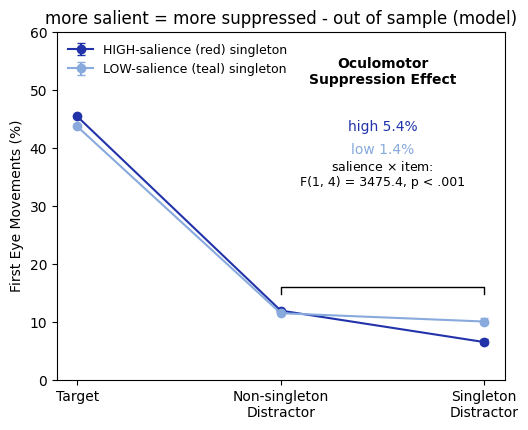

model rates per singleton position (%):
 sal  pos    t   ns    s
high    2 45.4 12.1  6.2
high    3 45.4 12.1  6.2
high    4 45.6 11.9  6.8
high    5 45.5 11.8  7.4
high    6 45.4 12.1  6.2
 low    2 43.7 11.7  9.6
 low    3 43.8 11.6  9.7
 low    4 43.8 11.4 10.5
 low    5 43.8 11.3 11.0
 low    6 43.7 11.7  9.6 

2 x 2 repeated-measures ANOVA (unit: the five singleton positions)
    Source      SS  ddof1  ddof2      MS         F  p_unc  p_GG_corr    ng2  eps
       sal 11.9147      1      4 11.9147 3509.2029 0.0000     0.0000 0.8031  1.0
      item 58.8820      1      4 58.8820  109.1698 0.0005     0.0005 0.9527  1.0
sal * item 19.9579      1      4 19.9579 3475.4149 0.0000     0.0000 0.8723  1.0


In [16]:
# one condition pair (schematic colors, NOT Stilwell's exact CIE
# colors - the aim is the qualitative gradient): BLUE target with a
# RED singleton (high salience: far from blue) vs a TEAL singleton
# (low salience: near blue). Channels come out of channel_maps in
# greyscale, the training units.
TC = "blue"
COND = {"high": "red", "low": "teal"}

def item_rates(sc_, sl):
    """One display -> model landing probabilities (%) for the
    target, the non-singleton average, and the singleton
    (target slot 1, singleton at slot sl, zero histories)."""
    ch = channel_maps(display_for(6, 1, sl, TC, sc_), TC)
    F_ = []
    for i_, (py_, px_) in enumerate(centers(6)):
        sv = ch[:, py_, px_].float()
        F_.append(learned["g_C"]*sv[0] + learned["g_F"]*sv[1])
    p = torch.softmax(torch.stack(F_)[None], 1)[0]
    pt, ps = p[0].item(), p[sl - 1].item()
    return pt * 100, (1 - pt - ps) / 4 * 100, ps * 100

rows_ = []
for sal, sc_ in COND.items():
    for sl in range(2, 7):                 # five singleton positions
        t_r, ns_r, s_r = item_rates(sc_, sl)
        rows_.append((sal, sl, t_r, ns_r, s_r))
res = pd.DataFrame(rows_, columns=["sal", "pos", "t", "ns", "s"])

# suppression difference across salience = the salience x item-type
# interaction: 2 (high/low) x 2 (non-singleton/singleton)
# repeated-measures ANOVA, singleton position as the unit
long = res.melt(id_vars=["sal", "pos"], value_vars=["ns", "s"],
                var_name="item", value_name="rate")
aov = pg.rm_anova(dv="rate", within=["sal", "item"], subject="pos",
                  data=long, detailed=True)

order = ["t", "ns", "s"]
x = np.arange(3)
plt.figure(figsize=(5.4, 4.4))
supp_ = {}
for sal, c_ in (("high", "#2233aa"), ("low", "#88aadd")):
    g_ = res[res.sal == sal][order]
    y = g_.mean().values
    idx_b = np.random.default_rng(0).integers(0, len(g_),
                                              (10000, len(g_)))
    lo, hi = np.percentile(g_.values[idx_b].mean(1), [2.5, 97.5], axis=0)
    plt.errorbar(x, y, yerr=np.stack([y - lo, hi - y]), color=c_,
                 marker="o", ms=6, capsize=3, lw=1.5,
                 label=f"{sal.upper()}-salience ({COND[sal]}) singleton")
    supp_[sal] = y[1] - y[2]
# the suppression bracket: non-singleton vs singleton distractor
top = res.ns.max() + 4
plt.plot([1, 1, 2, 2], [top - 1.2, top, top, top - 1.2], "k-", lw=1)
irow = aov[aov.Source == "sal * item"].iloc[0]
plt.text(1.5, 51, "Oculomotor\nSuppression Effect", ha="center",
         fontsize=10, fontweight="bold")
plt.text(1.5, 43, f"high {supp_['high']:.1f}%", ha="center",
         fontsize=10, color="#2233aa")
plt.text(1.5, 39, f"low {supp_['low']:.1f}%", ha="center",
         fontsize=10, color="#88aadd")
p_i = irow["p_unc"]
plt.text(1.5, 33.5, "salience $\\times$ item:\n"
         f"F({int(irow.ddof1)}, {int(irow.ddof2)}) = {irow.F:.1f}, "
         + ("p < .001" if p_i < .001 else f"p = {p_i:.3f}"),
         ha="center", fontsize=9)
plt.xticks(x, ["Target", "Non-singleton\nDistractor",
               "Singleton\nDistractor"])
plt.ylabel("First Eye Movements (%)")
plt.ylim(0, 60)
plt.legend(loc="upper left", frameon=False, fontsize=9)
plt.title("more salient = more suppressed - out of sample (model)")
plt.tight_layout()
plt.show()

print("model rates per singleton position (%):")
print(res.round(1).to_string(index=False), "\n")
print("2 x 2 repeated-measures ANOVA (unit: the five singleton positions)")
print(aov.round(4).to_string(index=False))

The mechanism: `g_C` weighs each item's projection onto the
goal's color axis. A low-salience singleton sits NEAR the target
color, so its projection is only mildly negative — it largely
escapes suppression. A high-salience singleton points the opposite
way and takes the full hit. The gradient falls out of one signed
gain applied to colors the fit never saw.

**9c. Location priming.** Saccades to the target roughly double
when the target repeats its location; saccades to the singleton
drop when IT repeats. The selection-history machinery at work.

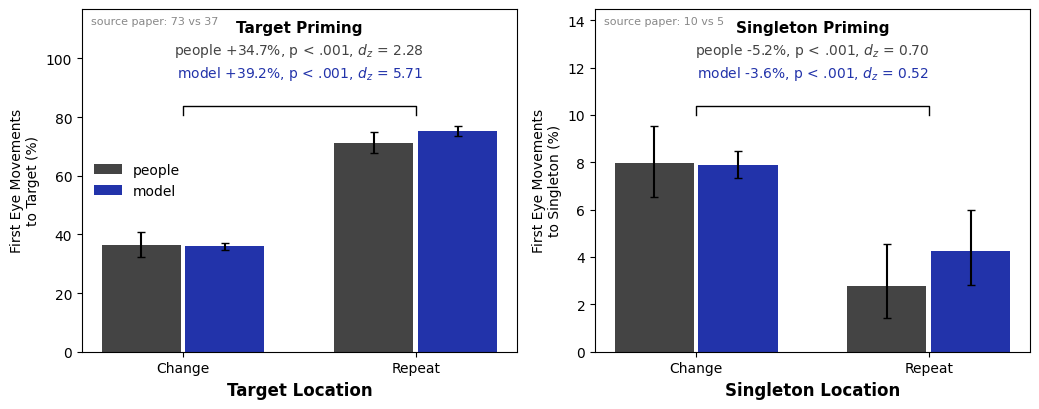

people, target location: repeat vs change (paired across 66 held-out subjects)
    T  dof alternative  p_val           CI95  cohen_d  power      BF10
18.55   65   two-sided    0.0 [30.99, 38.47]   2.1078    1.0 2.865e+24 

model, target location: repeat vs change (paired across 66 held-out subjects)
      T  dof alternative  p_val           CI95  cohen_d  power      BF10
46.3666   65   two-sided    0.0 [37.53, 40.91]   6.4817    1.0 7.933e+47 

people, singleton location: repeat vs change (paired across 66 held-out subjects)
      T  dof alternative  p_val           CI95  cohen_d  power      BF10
-5.7009   65   two-sided    0.0 [-7.01, -3.37]   0.8101    1.0 4.592e+04 

model, singleton location: repeat vs change (paired across 66 held-out subjects)
      T  dof alternative  p_val           CI95  cohen_d  power    BF10
-4.2402   65   two-sided 0.0001 [-5.36, -1.93]   0.7239 0.9999 285.616 



In [17]:
ev2 = ev.copy()
ev2["block"] = pd.to_numeric(ev2["block"], errors="coerce").fillna(0.0)
ev2["trial"] = pd.to_numeric(ev2["trial"], errors="coerce")
ev2["subj"] = ev2["subj"].astype(str)
ev2 = ev2.sort_values(["study", "subj", "block", "trial"])
ev2["prevT"] = ev2.groupby(["study", "subj"]).targLoc.shift(1)
ev2["prevS"] = ev2.groupby(["study", "subj"]).singLoc.shift(1)
key = ["study", "subj", "block", "trial"]
sacc2 = sacc.merge(ev2[key + ["prevT", "prevS"]], on=key, how="left")

# regenerated saccades for ALL trials (9a's logic, whole dataset):
# one draw per real trial from the predicted probabilities
gen2 = torch.Generator().manual_seed(1)
sim2 = torch.multinomial(prob, 1, generator=gen2).squeeze(1)
simch2 = torch.zeros(N, 6); simch2[torch.arange(N), sim2] = 1

def priming_panel(ax, m_change, m_repeat, pick, effect_name,
                  what, paper):
    """Paper-style priming panel: Change vs Repeat bars (people +
    model), per-subject means over held-out people, bootstrapped
    95% CI error bars, model bars from the regenerated saccades,
    and a bracket annotated with the effect (repeat - change), p,
    and d_z from a paired t-test across subjects."""
    frames = []
    for m_ in (m_change, m_repeat):
        d_ = pd.DataFrame(dict(
            si=tt["si"][m_].numpy(),
            obs=(chose[m_] * pick[m_]).sum(1).numpy(),
            mod=(simch2[m_] * pick[m_]).sum(1).numpy()))
        frames.append(d_.groupby("si").mean() * 100)
    p2 = frames[0].join(frames[1], lsuffix="_ch", rsuffix="_rep").dropna()
    idx_b = np.random.default_rng(0).integers(0, len(p2), (10000, len(p2)))
    ci = pd.DataFrame(np.percentile(p2.values[idx_b].mean(1),
                                    [2.5, 97.5], axis=0).T,
                      index=p2.columns, columns=["lo", "hi"])
    series = [("obs", "#444444", "people"), ("mod", "#2233aa", "model")]
    tests_, top = {}, 0.0
    x = np.arange(2)
    for k, (w_, c_, lab) in enumerate(series):
        cols = [w_ + "_ch", w_ + "_rep"]
        y = p2[cols].mean().values
        e = np.stack([y - ci.lo[cols], ci.hi[cols] - y])
        ax.bar(x + (k - 0.5) * 0.36, y, 0.34, yerr=e, capsize=3,
               color=c_, label=lab)
        tests_[w_] = pg.ttest(p2[w_ + "_rep"], p2[w_ + "_ch"],
                              paired=True)
        top = max(top, (y + e[1]).max())
    # the bracket, then one annotation line per series
    ax.plot([0, 0, 1, 1],
            [top * 1.05, top * 1.09, top * 1.09, top * 1.05],
            "k-", lw=1)
    ax.text(0.5, top * 1.42, effect_name, ha="center", fontsize=11,
            fontweight="bold")
    for k, (w_, c_, lab) in enumerate(series):
        t_ = tests_[w_]
        eff = p2[w_ + "_rep"].mean() - p2[w_ + "_ch"].mean()
        dz = abs(t_["T"].iloc[0]) / np.sqrt(len(p2))
        ax.text(0.5, top * (1.32 - 0.10 * k),
                f"{lab} {eff:+.1f}%, {p_str(t_)}, $d_z$ = {dz:.2f}",
                ha="center", fontsize=10, color=c_)
    ax.set_xticks(x, ["Change", "Repeat"])
    ax.set_xlabel(what, fontsize=12, fontweight="bold")
    ax.set_ylabel(f"First Eye Movements\nto {what.split()[0]} (%)")
    ax.set_ylim(0, top * 1.52)
    ax.text(0.02, 0.98, paper, transform=ax.transAxes, va="top",
            fontsize=8, color="#888888")
    return tests_, len(p2)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
tr = test & first & torch.tensor(sacc2.prevT.values == sacc.targLoc.values)
tc_ = test & first & torch.tensor((sacc2.prevT.values != sacc.targLoc.values)
                                  & ~np.isnan(sacc2.prevT.values))
tests_T, nT = priming_panel(axes[0], tc_, tr, isT, "Target Priming",
                            "Target Location", "source paper: 73 vs 37")
axes[0].legend(loc="center left", frameon=False)
sr = test & first & sing_present & torch.tensor(
    (sacc2.prevS.values == sacc.singLoc.values) & (sacc2.prevS.values > 0))
sc2 = test & first & sing_present & torch.tensor(
    sacc2.prevS.values != sacc.singLoc.values)
tests_S, nS = priming_panel(axes[1], sc2, sr, isS, "Singleton Priming",
                            "Singleton Location", "source paper: 10 vs 5")
plt.tight_layout()
plt.show()

for lab, tests_, n_ in [("target location: repeat vs change", tests_T, nT),
                        ("singleton location: repeat vs change",
                         tests_S, nS)]:
    for w_, who in (("obs", "people"), ("mod", "model")):
        print(f"{who}, {lab} (paired across {n_} held-out subjects)")
        print(tests_[w_].round(4).to_string(index=False), "\n")

## 10. The spatial prior, trial by trial

Section 4 used made-up history; here are the REAL trained memories
of one held-out person. Before each display appears, the prior
`beta_T*h_T + beta_D*h_D` already tilts toward their last target
location — the green circle marks it; watch the bump follow it
from trial to trial. The right bar chart quantifies this across
all held-out trials.

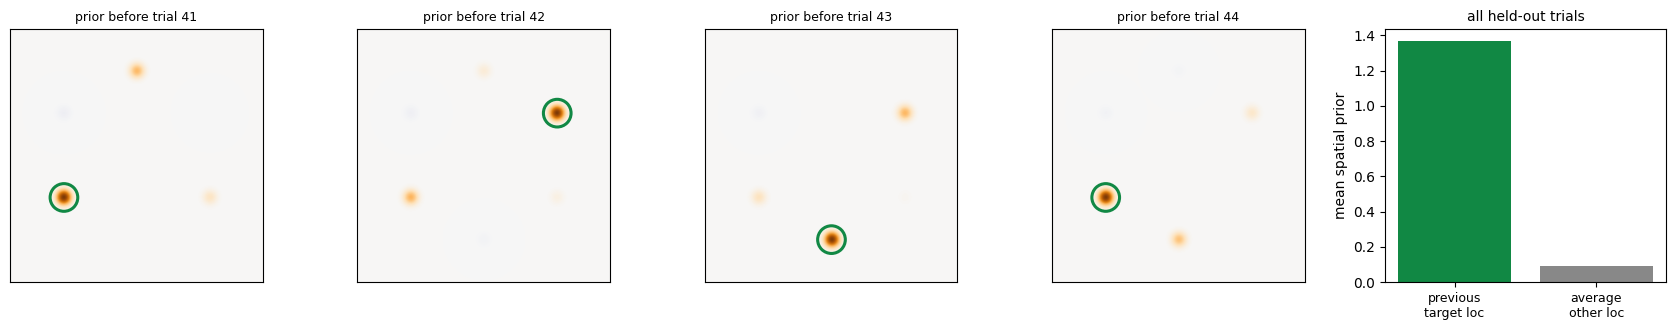

prior at previous target location: +1.366  vs other locations: +0.090


In [18]:
si_np = tt["si"].numpy(); ti_np = tt["ti"].numpy()
subj = int(np.unique(si_np[test.numpy()])[0])       # one held-out person
trials = np.sort(ti_np[(si_np == subj)])[40:44]     # four consecutive trials

with torch.no_grad():
    fig, axes = plt.subplots(1, 5, figsize=(17, 3.4))
    for ax, t in zip(axes[:4], trials):
        hT_t = memT[subj, t].numpy(); hD_t = memD[subj, t].numpy()
        # the prior, location by location (learned weights)...
        prior_t = (learned["beta_T"]*hT_t
                   + learned["beta_D"]*hD_t)
        pm = selection_history_map(prior_t)     # ...then painted, display only
        v = max(np.abs(pm).max(), 1e-9)
        ax.imshow(pm, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
        prev = int(tt["eT"][subj, t-1].argmax()) if t > 0 else None
        if prev is not None:
            px, py = (pos[prev][0]+0.75)/1.5*IMG, (pos[prev][1]+0.75)/1.5*IMG
            ax.add_patch(plt.Circle((px, py), 14, fill=False,
                                    ec="#118844", lw=2.2))
        ax.set_title(f"prior before trial {int(t)}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    # across all held-out trials: prior at prev-target loc vs elsewhere
    prior_slots = learned["beta_T"]*memT + learned["beta_D"]*memD
    at_prev, at_other = [], []
    for s in np.unique(si_np[test.numpy()]):
        eT_s = tt["eT"][int(s)]
        T_ = int(ti_np[si_np == int(s)].max()) + 1
        for t in range(1, T_):
            prev = int(eT_s[t-1].argmax())
            if eT_s[t-1].sum() == 0:
                continue
            vals = prior_slots[int(s), t].numpy()
            at_prev.append(vals[prev])
            at_other.append(np.delete(vals, prev).mean())
    axes[4].bar([0, 1], [np.mean(at_prev), np.mean(at_other)],
                color=["#118844", "#888888"])
    axes[4].set_xticks([0, 1])
    axes[4].set_xticklabels(["previous\ntarget loc", "average\nother loc"],
                            fontsize=9)
    axes[4].set_ylabel("mean spatial prior")
    axes[4].set_title("all held-out trials", fontsize=10)
    plt.tight_layout()
    plt.show()
print(f"prior at previous target location: {np.mean(at_prev):+.3f}  "
      f"vs other locations: {np.mean(at_other):+.3f}")

## Recap

| The model receives | It returns |
| --- | --- |
| a picture, a goal, the trial history | a probability per item |

We laid out the structure (§1) and displays (§2), built the
goal-modified salience map (§3) and the leaky-accumulator history
map (§4), summed them into THE priority map (§5), assembled
`priority_map` -> `predict_saccade` with a worked example (§6),
trained the six numbers on all the real first saccades through an
exact cache (§7), evaluated on people the model never saw (§8),
reproduced suppression, the out-of-sample salience gradient, and
location priming (§9), and watched the spatial prior track the
previous target trial by trial (§10). (Why no attention window?
See the §1 note: in this scope it is a shared scalar the gains
absorb — tested three ways in `RESULTS.md`.)

More: `RESULTS.md` (the results ledger) and
`docs/priority_field_visual_search_model.md` (the theory).